# Resume Dataset — Exploratory Data Analysis & Job Category Classification

**Dataset:** `Ndataset.csv`


## 1. Setup & Imports

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_columns", None)


## 2. Load the Data

In [4]:
df = pd.read_csv(r"C:\Users\apeks\OneDrive\Desktop\Seventh\Project\resumeParser\resume_parser\datasets\Ndataset_plus10000.csv")
print("Shape:", df.shape)
df.head()


Shape: (25100, 9)


,job_category,resume_text,skills,education,experience,email,phone,text_length,skills_count
0,Technical Writer,Pamela Garcia - Technical Writer based in Dhar...,"docs-as-code, swagger, openapi, api documentat...",Bachelor's in Journalism,10+ years of professional experience,ymcintyre@yahoo.com,985-8849206,424,7.0
1,Web Developer,Kimberly Smith - Web Developer based in Butwal...,"responsive design, plugin development, wordpre...",Bachelor's in Computer Science,1 year of professional experience,valdezeric@yahoo.com,981-1268485,444,7.0
2,Vue.js Developer,Tracy Jones - Vue.js Developer based in Kathma...,"node.js, php, javascript, laravel, typescript,...",Bachelor's in Software Engineering,7 years of professional experience,jennifer99@gmail.com,987-6153994,410,6.0
3,WordPress Developer,Jody Silva - WordPress Developer based in Dhar...,"JavaScript, Magento, HTML, PHP, Theme Developm...",Bachelor's in Computer Engineering,1 year of professional experience,susan71@yahoo.com,986-7429739,394,7.0
4,React Intern,"Norman Rangel - React Intern based in Chitwan,...","Research, Problem Solving, CSS, Python, Git, B...",Currently pursuing Bachelor's in Computer Science,Fresher / No prior experience,ann12@yahoo.com,983-7451002,416,7.0


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   job_category  25100 non-null  str    
 1   resume_text   25100 non-null  str    
 2   skills        25100 non-null  str    
 3   education     25100 non-null  str    
 4   experience    25100 non-null  str    
 5   email         25100 non-null  str    
 6   phone         25100 non-null  str    
 7   text_length   25100 non-null  int64  
 8   skills_count  25096 non-null  float64
dtypes: float64(1), int64(1), str(7)
memory usage: 1.7 MB


## 4. Target Variable — `job_category`

There are 151 unique job categories. Let's see how balanced they are.

In [9]:
n_classes = df["job_category"].nunique()
print("Number of unique job categories:", n_classes)

vc = df["job_category"].value_counts()
print("\nMost common categories:")
print(vc.head(10))
print("\nLeast common categories:")
print(vc.tail(10))


Number of unique job categories: 151

Most common categories:
job_category
QA Analyst                         191
Infrastructure Support Engineer    184
Backend Intern                     182
Software Architect                 181
Django Developer                   180
WordPress Developer                179
PHP Developer                      179
AR/VR Developer                    179
Motion Designer                    179
Technology Consultant              178
Name: count, dtype: int64

Least common categories:
job_category
Cloud Engineer             152
Frontend Developer         152
Cloud Administrator        152
FastAPI Developer          151
QA Engineer                150
Flutter Developer          149
Odoo Developer             149
.NET Developer             148
Infrastructure Engineer    143
IoT Developer              141
Name: count, dtype: int64


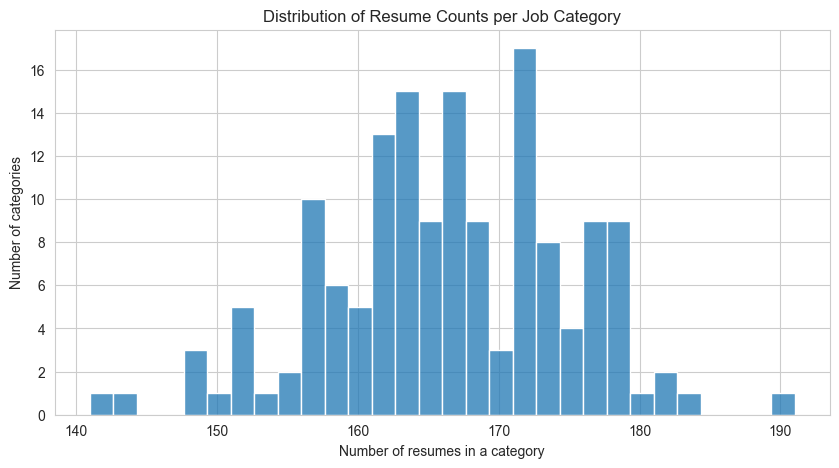

Categories are fairly balanced: min = 141 , max = 191 , mean = 166.2


In [10]:
plt.figure(figsize=(10, 5))
sns.histplot(vc.values, bins=30, kde=False)
plt.title("Distribution of Resume Counts per Job Category")
plt.xlabel("Number of resumes in a category")
plt.ylabel("Number of categories")
plt.show()

print("Categories are fairly balanced: min =", vc.min(), ", max =", vc.max(), ", mean =", round(vc.mean(), 1))


C:\Users\apeks\AppData\Local\Temp\ipykernel_19768\401875646.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top20.values, y=top20.index, palette="viridis")


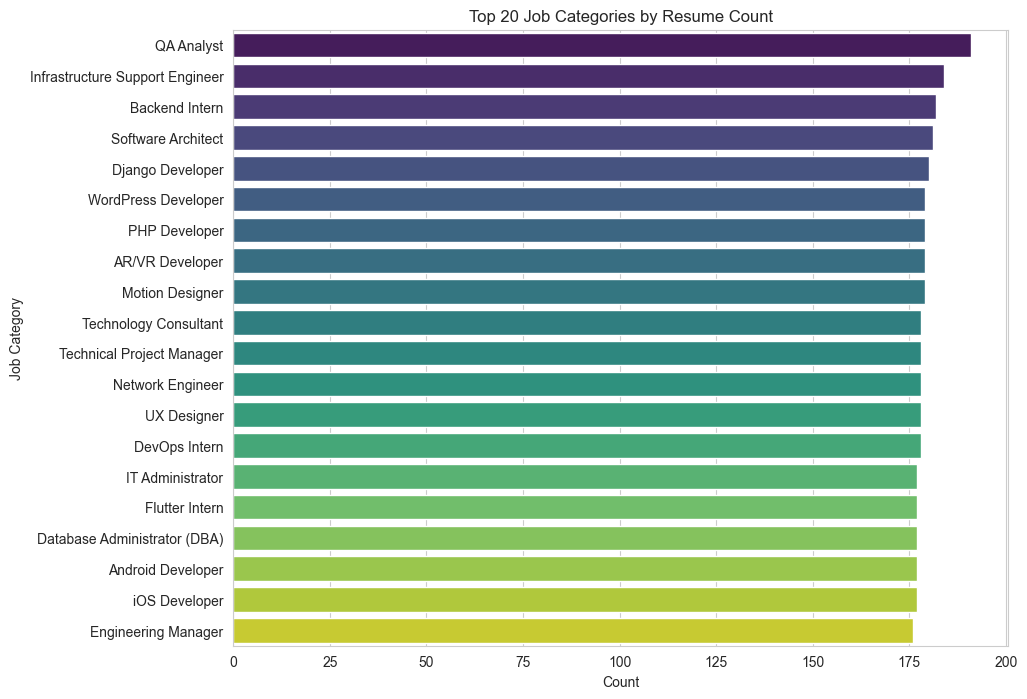

In [11]:
# Top 20 categories bar chart
plt.figure(figsize=(10, 8))
top20 = vc.head(20)
sns.barplot(x=top20.values, y=top20.index, palette="viridis")
plt.title("Top 20 Job Categories by Resume Count")
plt.xlabel("Count")
plt.ylabel("Job Category")
plt.show()


## 5. Numeric Feature Exploration — `text_length` and `skills_count`

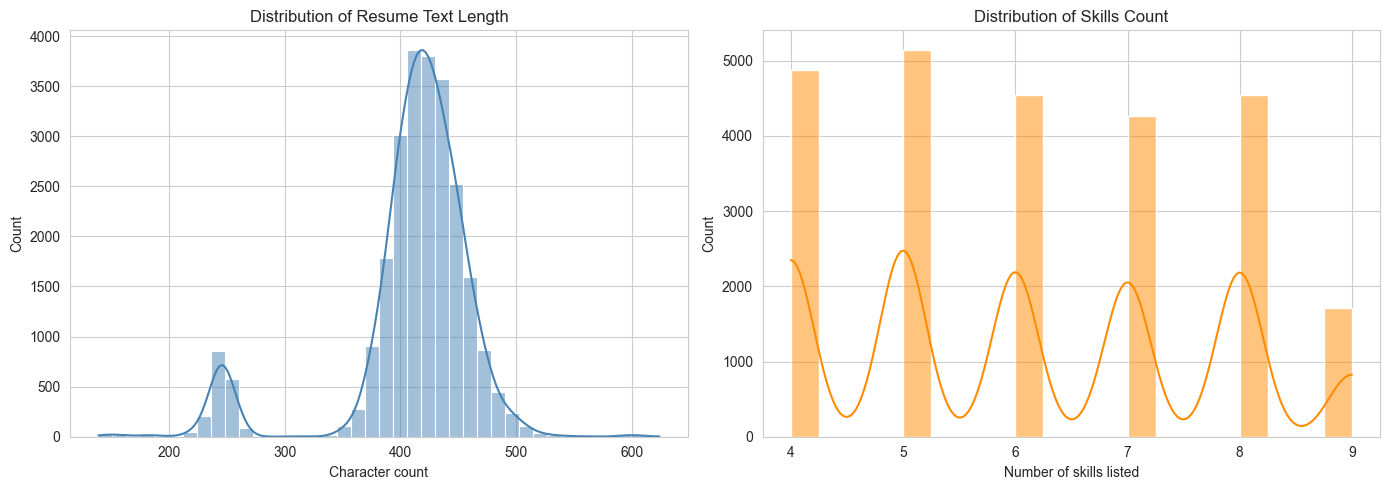

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df["text_length"], bins=40, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of Resume Text Length")
axes[0].set_xlabel("Character count")

sns.histplot(df["skills_count"], bins=20, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribution of Skills Count")
axes[1].set_xlabel("Number of skills listed")

plt.tight_layout()
plt.show()


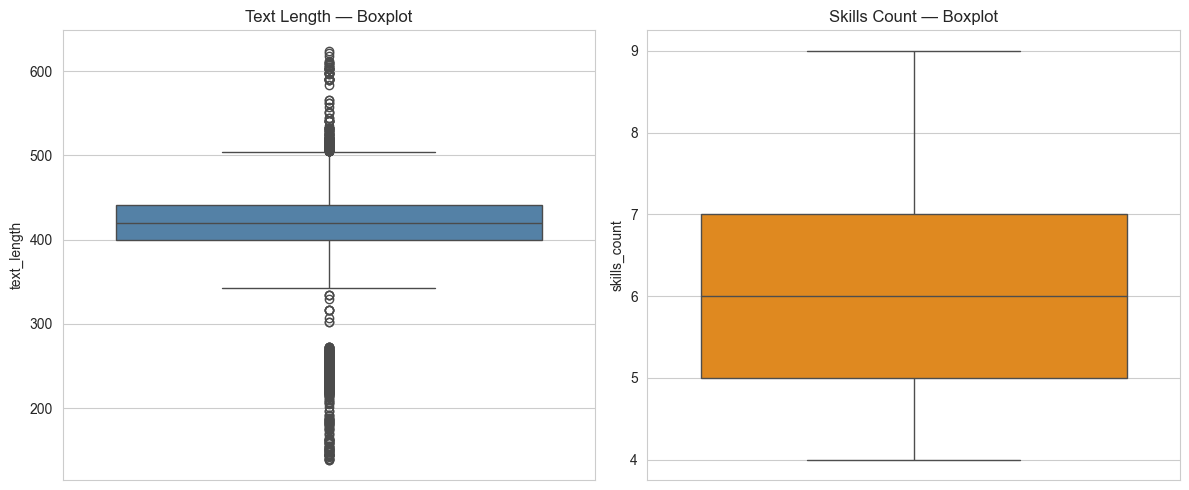

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(y=df["text_length"], ax=axes[0], color="steelblue")
axes[0].set_title("Text Length — Boxplot")
sns.boxplot(y=df["skills_count"], ax=axes[1], color="darkorange")
axes[1].set_title("Skills Count — Boxplot")
plt.tight_layout()
plt.show()


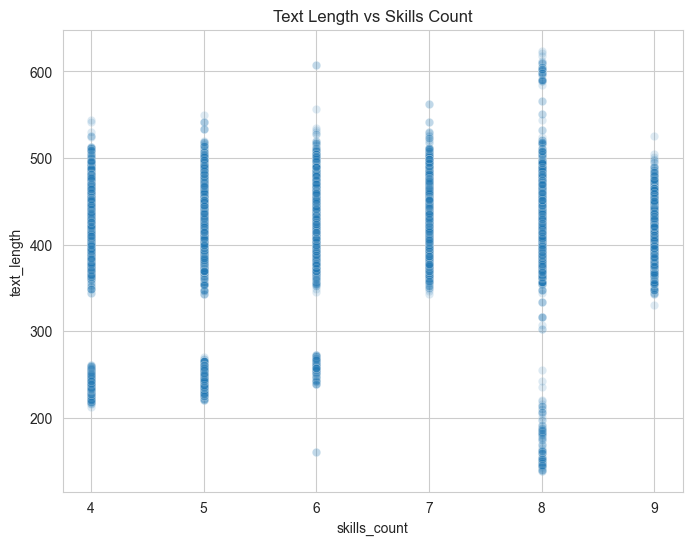

Correlation between text_length and skills_count: 0.178


In [14]:
# Relationship between text length and number of skills listed
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x="skills_count", y="text_length", alpha=0.15)
plt.title("Text Length vs Skills Count")
plt.show()

corr = df[["text_length", "skills_count"]].corr().iloc[0, 1]
print(f"Correlation between text_length and skills_count: {corr:.3f}")


## 6. Education & Experience Fields

In [15]:
print("Top 10 education values:")
print(df["education"].value_counts().head(10))


Top 10 education values:
education
Bachelor's in Computer Engineering                         3663
Bachelor's in Computer Science                             3044
Bachelor's in Information Technology                       2996
Bachelor's in Business Administration                       723
Master's in Computer Science                                714
Diploma in Computer Networking                              613
Currently pursuing Bachelor's in Information Technology     602
Currently pursuing Bachelor's in Computer Engineering       587
Final year Bachelor's student                               586
CCNA Certification                                          582
Name: count, dtype: int64


C:\Users\apeks\AppData\Local\Temp\ipykernel_19768\2070746698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=edu_top.values, y=edu_top.index, palette="mako")


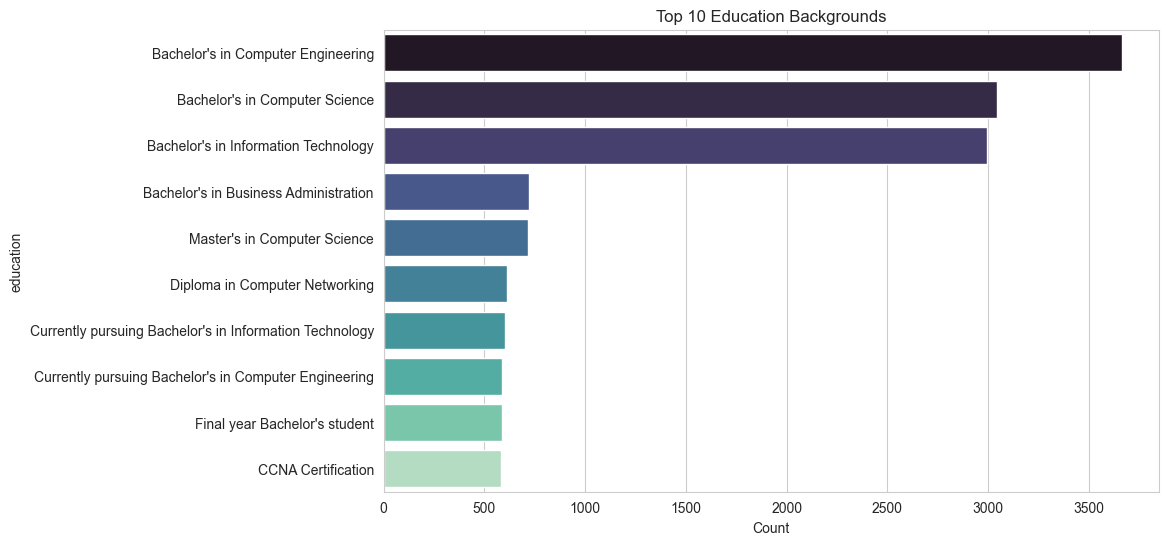

In [16]:
plt.figure(figsize=(10, 6))
edu_top = df["education"].value_counts().head(10)
sns.barplot(x=edu_top.values, y=edu_top.index, palette="mako")
plt.title("Top 10 Education Backgrounds")
plt.xlabel("Count")
plt.show()


In [17]:
print("Top 10 experience values:")
print(df["experience"].value_counts().head(10))


Top 10 experience values:
experience
10+ years of professional experience                                                                   1635
1 year of professional experience                                                                      1616
3 years of professional experience                                                                     1579
5 years of professional experience                                                                     1572
4 years of professional experience                                                                     1547
6 months of internship experience                                                                      1536
2 years of professional experience                                                                     1531
Fresher / No prior experience                                                                          1526
7 years of professional experience                                                                 

## 7. Skills Text Analysis

`skills` is a comma-separated string per resume. Let's flatten it out and look at the
most frequently mentioned individual skills across the whole dataset.

C:\Users\apeks\AppData\Local\Temp\ipykernel_19768\2956903665.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_skills.values, y=top_skills.index, palette="crest")


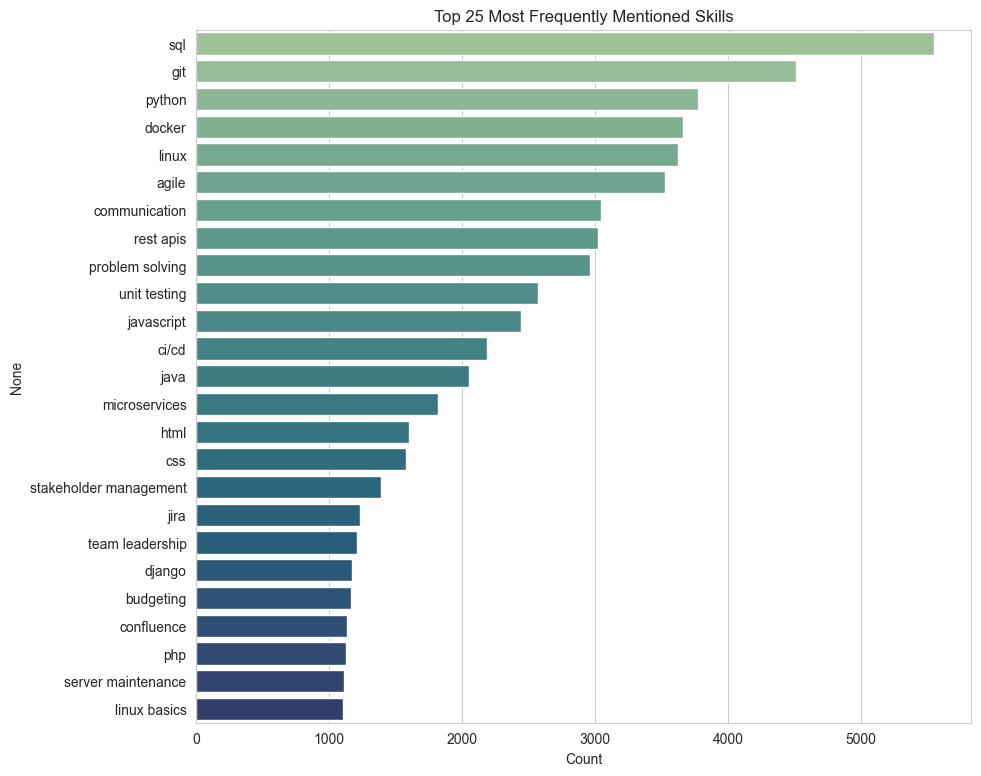

In [18]:
all_skills = (
    df["skills"]
    .str.lower()
    .str.split(",")
    .explode()
    .str.strip()
)
all_skills = all_skills[all_skills != ""]

skill_counts = Counter(all_skills)
top_skills = pd.Series(dict(skill_counts)).sort_values(ascending=False).head(25)

plt.figure(figsize=(10, 9))
sns.barplot(x=top_skills.values, y=top_skills.index, palette="crest")
plt.title("Top 25 Most Frequently Mentioned Skills")
plt.xlabel("Count")
plt.show()


## 8. Correlation Heatmap (Numeric Features)

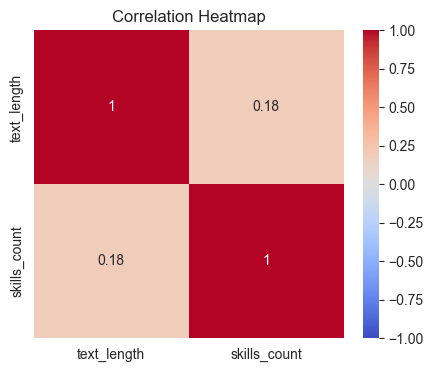

In [19]:
numeric_df = df[["text_length", "skills_count"]]
plt.figure(figsize=(5, 4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Correlation Heatmap")
plt.show()
